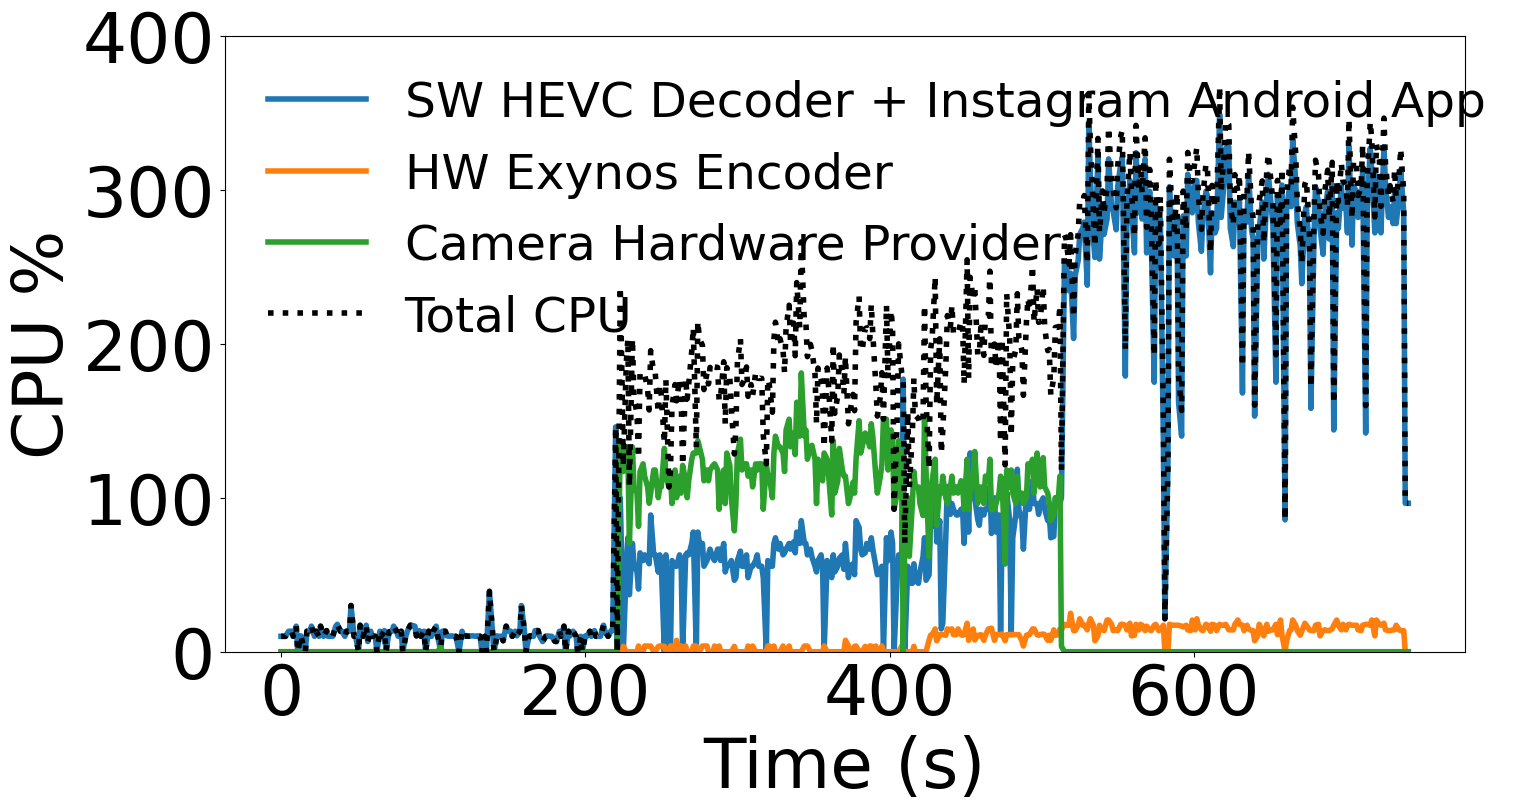

In [8]:
import matplotlib.pyplot as plt
import re
import pandas as pd
from datetime import datetime

# Read the log file
with open('insta_live_codecs_logs.txt', 'r') as f:
    content = f.read()

# Split content into blocks starting with each timestamp
blocks = re.split(r'Timestamp: ', content)[1:]

data = []
for block in blocks:
    lines = block.splitlines()
    if not lines:
        continue

    # Parse timestamp from the first line of the block
    timestamp_str = lines[0].strip()
    try:
        ts = datetime.strptime(timestamp_str, '%a %b %d %H:%M:%S %Z %Y')
    except ValueError:
        continue

    # Extract CPU for each process (assuming multiple process lines)
    for line in lines[1:]:
        stripped_line = line.strip()
        if not stripped_line:
            continue
        parts = re.split(r'\s+', stripped_line)
        if len(parts) > 8 and parts[0].isdigit():
            try:
                pid = int(parts[0])
                cpu = float(parts[8])  # %CPU
                data.append({'time': ts, 'pid': pid, 'cpu': cpu})
            except ValueError:
                pass

# Create DataFrame and sort by time
if not data:
    print("No CPU data found.")
else:
    df = pd.DataFrame(data).sort_values('time')
    df['time_relative'] = (df['time'] - df['time'].min()).dt.total_seconds()

    # Separate Instagram (PID 9979)
    insta_df = df[df['pid'] == 9979][['time_relative', 'cpu']].sort_values('time_relative')
    hw_df = df[df['pid'] == 1020][['time_relative', 'cpu']].sort_values('time_relative')
    hw_cam_df = df[df['pid'] == 978][['time_relative', 'cpu']].sort_values('time_relative')

    # Sum CPU for all other PIDs (Software Codec)
    sw_df = df[df['pid'] != 9979].groupby('time_relative')['cpu'].sum().reset_index().sort_values('time_relative')
    df_filtered = df.drop(df[df['pid'] == 1020].index)
    df_filtered = df_filtered.drop(df[df['pid'] == 978].index)
    # Total CPU
    total_df = df_filtered.groupby('time_relative')['cpu'].sum().reset_index().sort_values('time_relative')
    all_df = df.groupby('time_relative')['cpu'].sum().reset_index().sort_values('time_relative')
    universal_font_size = 50
    # Plot CPU utilization
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.plot(total_df['time_relative'], total_df['cpu'], linewidth=4, label="SW HEVC Decoder + Instagram Android App")
    ax.plot(hw_df['time_relative'], hw_df['cpu'], linewidth=4, label="HW Exynos Encoder")
    ax.plot(hw_cam_df['time_relative'], hw_cam_df['cpu'], linewidth=4, label="Camera Hardware Provider")
    ax.plot(all_df['time_relative'], all_df['cpu'], linewidth=4, label="Total CPU", linestyle=':', color='black')
    ax.set_ylabel('CPU %', fontsize=universal_font_size)
    ax.set_ylim(0, 400)
    ax.set_xlabel('Time (s)', fontsize=universal_font_size)
    ax.tick_params(axis='both', labelsize=universal_font_size)
    ax.legend(fontsize=35, loc='upper left', frameon=False)
    plt.savefig('../Plots/insta_live_codecs_cpu_utilization.png')
    plt.show()